In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [3]:
import os
print(os.getcwd())

c:\Users\DeLL\Desktop\life-expectancy-ml-project\notebooks


In [4]:
import os
print(os.listdir(".."))

['.git', '.gitignore', 'data', 'images', 'notebooks', 'README', 'README.md', 'src']


In [5]:
import os
print(os.listdir("../data"))

['Life Expectancy Data.csv']


In [6]:
df = pd.read_csv("../data/Life Expectancy Data.csv")

In [7]:
df.columns = df.columns.str.strip()

In [8]:
df = df.dropna(subset = ["Life expectancy"])

In [9]:
X, y = df.drop(columns = ["Life expectancy"]), df["Life expectancy"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 13)

In [11]:
for col in ["GDP", "Population", "Hepatitis B"]:
    X_train[col] = X_train.groupby("Country")[col].transform(
        lambda x: x.fillna(x.median()))
    global_median = X_train[col].median()
    X_train[col] = X_train[col].fillna(global_median)
    medians = X_train.groupby("Country")[col].median()
    X_test[col] = X_test[col].fillna(X_test["Country"].map(medians))
    X_test[col] = X_test[col].fillna(global_median)

C:\Users\DeLL\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\DeLL\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\DeLL\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\DeLL\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\DeLL\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\DeLL\AppData\Roaming\Python\Pyt

In [12]:
remaining_cols = [
    "Total expenditure",
    "Alcohol",
    "Income composition of resources",
    "Schooling",
    "thinness 5-9 years",
    "thinness  1-19 years",
    "BMI",
    "Diphtheria",
    "Polio",
    "Adult Mortality"
]

for col in remaining_cols:
    median = X_train[col].median()
    X_train[col] = X_train[col].fillna(median)
    X_test[col] = X_test[col].fillna(median)

In [13]:
categorical_cols = ["Status"]
numeric_cols = [
   'Year','Adult Mortality',
   'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
   'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure',
   'Diphtheria', 'HIV/AIDS', 'GDP', 'Population',
   'thinness  1-19 years', 'thinness 5-9 years',
   'Income composition of resources', 'Schooling'
]

In [14]:
preprocessor = ColumnTransformer(
    transformers = [
        ("cat", OneHotEncoder(
            drop = "if_binary",
            handle_unknown = "ignore",
            # sprase_output = False
        ), categorical_cols),
        ("num", StandardScaler(), numeric_cols)
    ]
)

In [15]:
pipe = Pipeline([
    ("preprocessing", preprocessor), 
    ("regressor", LinearRegression()),
])

In [16]:
cv_scores = cross_val_score(
    pipe, X_train, y_train, cv = 5, scoring = "r2")
print(f"CV Scores: {cv_scores}")
print(f"Mean CV Scores: {np.mean(cv_scores)}")
print(f"CV std: {np.std(cv_scores)}")

CV Scores: [0.82714487 0.82584167 0.80882798 0.77876751 0.82718647]
Mean CV Scores: 0.8135536998317272
CV std: 0.018729538590900912


In [17]:
pipe.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [18]:
y_pred = pipe.predict(X_test)

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

In [20]:
mse  = mean_squared_error(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

MSE: 16.50
MAE: 3.08
RMSE: 4.06
R²: 0.823


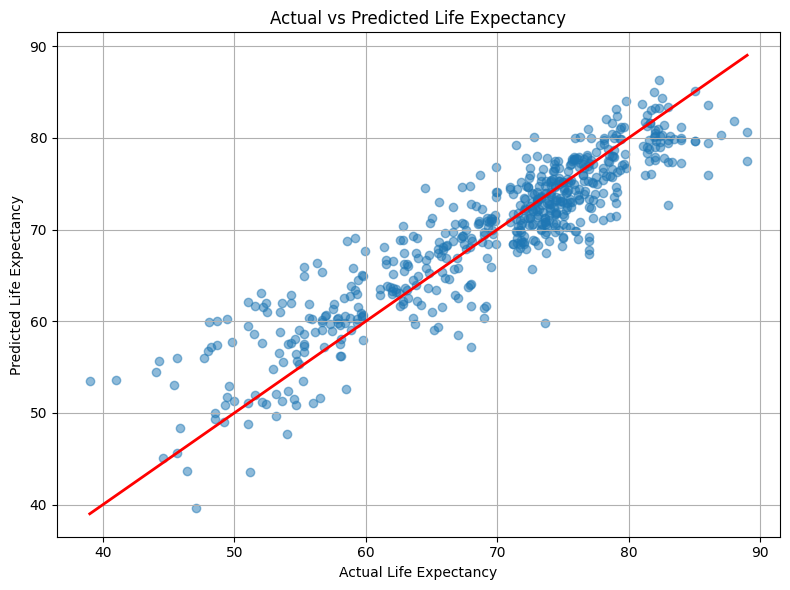

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

# Best prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.title("Actual vs Predicted Life Expectancy")
plt.grid()

plt.tight_layout()
plt.savefig("../images/prediction_plot.png", dpi=300)
plt.show()


In [23]:
linear = pipe.named_steps["regressor"]

In [24]:
importance = linear.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

print(feature_importance)

                            Feature  Importance
0                           Country   -1.454524
1                              Year   -1.454524
2                            Status   -1.454524
3                   Adult Mortality   -1.454524
4                     infant deaths   -1.454524
5                           Alcohol   -1.454524
6            percentage expenditure   -1.454524
7                       Hepatitis B   -1.454524
8                           Measles   -1.454524
9                               BMI   -1.454524
10                under-five deaths   -1.454524
11                            Polio   -1.454524
12                Total expenditure   -1.454524
13                       Diphtheria   -1.454524
14                         HIV/AIDS   -1.454524
15                              GDP   -1.454524
16                       Population   -1.454524
17             thinness  1-19 years   -1.454524
18               thinness 5-9 years   -1.454524
19  Income composition of resources   -1

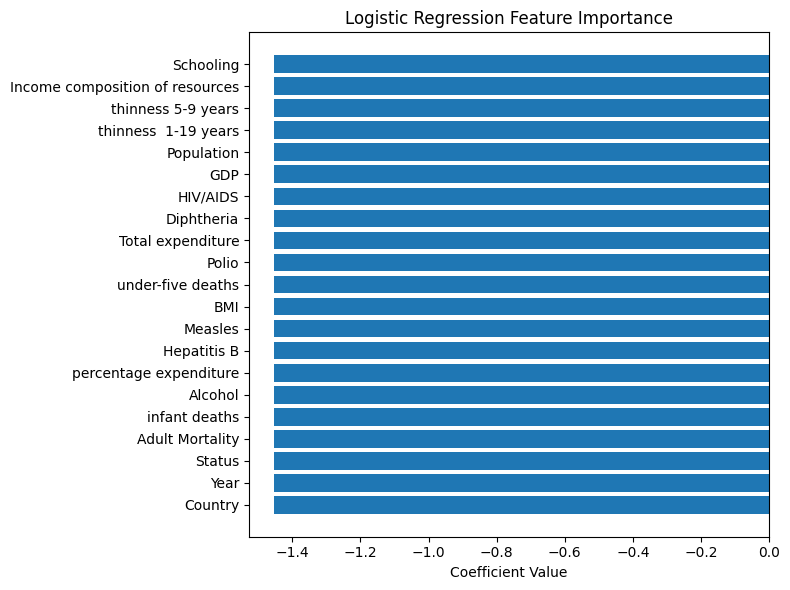

In [25]:
import matplotlib.pyplot as plt

feature_importance = feature_importance.sort_values(by="Importance")

plt.figure(figsize=(8,6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.title("Logistic Regression Feature Importance")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.savefig("../images/feature_importance_plot.png", dpi=300)
plt.show()